# Autonomous RAG 

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  
import warnings
#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel
from pprint import pprint
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langchain_groq import ChatGroq
warnings.filterwarnings("ignore")

C:\Users\kanha\AppData\Local\Temp\ipykernel_12036\2911865671.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [3]:
docs=TextLoader("research_notes.txt",encoding="utf-8").load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks=splitter.split_documents(docs)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"

)
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)
vectorstore=FAISS.from_documents(chunks,embeddings)
retriever=vectorstore.as_retriever()
retriever

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000282043BF990>, search_kwargs={})

In [4]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028204662E50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000282044C5010>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [16]:
from pydantic import BaseModel, Field

class RAGState(BaseModel):
    question: str
    sub_steps: List[str] = Field(default_factory=list)
    retrieved_docs: List[Document] = Field(default_factory=list)
    answer: str = ""

In [17]:
def plan_steps(state:RAGState):
    prompt=f" Break the question into 2 to 3 reasoning steps : \n\n {state.question}"
    result=llm.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip() ]

    return state.model_copy(update={"sub_steps":subqs})

In [18]:
def retriever_per_step(state:RAGState)->RAGState:
    all_docs=[]
    for sub in state.sub_steps:
        docs=retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs":all_docs})

In [19]:
def generate_answer(state:RAGState)->RAGState:
    context="\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt=f"""
                You are answering a complex quesiton using reasoning and retrieved documents.

                Question:{state.question}

                Relevant Information:
                {context}

                Now Synthesis a well-reasoned final answer.
        """

    result=llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":result})

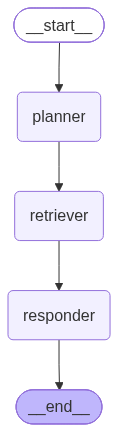

In [20]:
builder=StateGraph(RAGState)
builder.add_node("planner",plan_steps)
builder.add_node("retriever",retriever_per_step)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge('retriever',"responder")
builder.add_edge("responder",END)
graph=builder.compile()
graph

In [21]:
if __name__=="__main__":
    query="How do agent loops work and why are they useful in AI systems?"
    state=RAGState(question=query)
    final=graph.invoke(state)

    print("\n Reasoning Steps",final['sub_steps'])
    print("\n Final answer\n", final['answer'])


 Reasoning Steps ['To address the question of how agent loops work and why they are useful in AI systems, we can break it down into the following reasoning steps:', '1. **Understanding Agent Loops**:', '**Definition**: An agent loop refers to the cyclical process an autonomous agent (like a robot or a software program) goes through to perceive its environment, decide on actions, and then act upon those decisions.', '**Components**: The loop typically consists of perception (gathering data about the environment), reasoning (interpreting the data and making decisions), action (executing the decided action), and then back to perception to assess the outcome of the action and start the cycle again.', '2. **Mechanism and Operation**:', '**Continuous Feedback**: The loop operates in a continuous feedback cycle, allowing the agent to adapt to changes in its environment based on the outcomes of its actions.', '**Learning and Adaptation**: Over time, through machine learning algorithms, the ag